In [1]:
import pyclara
import pybdsim
import sdds
import numpy as np
import matplotlib.pyplot as plt

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
pyclara.Converters.elegant2bdsim_gmad("../Run/FEBE.lte", 
                                      elegant_twi="../Run/FEBE.twi")

Lattice written to:
FEBE_components.gmad
FEBE_sequence.gmad
FEBE_beam.gmad
All included in main file: 
 FEBE.gmad


In [3]:
pybdsim.Run.Bdsim("./FEBE.gmad","FEBE",ngenerate=5000)

0

Executable option> inputFileName              : ./FEBE.gmad    
Executable option> outputFileName             : FEBE           
Executable option> ngenerate                  : 5000           
Executable option> batch                      : true           
Executable option> bdsimPath                  : /Users/stewart.boogert/Dropbox/Physics/projects/clara-febe/clara-febe/pyclara/Notebooks/./
Executable option> distrFileMatchLength       : false          
BDSIM : version 1.7.7.develop
        (C) 2001-2026 Royal Holloway University London - GPLv3

        Reference: Computer Physics Communications, 107200 (2020)
                   https://doi.org/10.1016/j.cpc.2020.107200
                   https://arxiv.org/abs/1808.10745
        Website:   https://bdsim-collaboration.github.io/web/

parser> reading file /Users/stewart.boogert/Dropbox/Physics/projects/clara-febe/clara-febe/pyclara/Notebooks/./FEBE_components.gmad
parser> reading file /Users/stewart.boogert/Dropbox/Physics/projects/clar

In [4]:
pybdsim.Run.RebdsimOptics("FEBE.root","FEBE_optics.root")

0

Primary particle: e-
Analysis on "Event." beginning
Sampler analysis complete                           
Analysis on "Event." complete
Merging histograms from "Event" analysis
Result written to: FEBE_optics.root


In [5]:
o = pybdsim.DataPandas.REBDSIMOptics("./FEBE_optics.root")
po = o.get_optics()

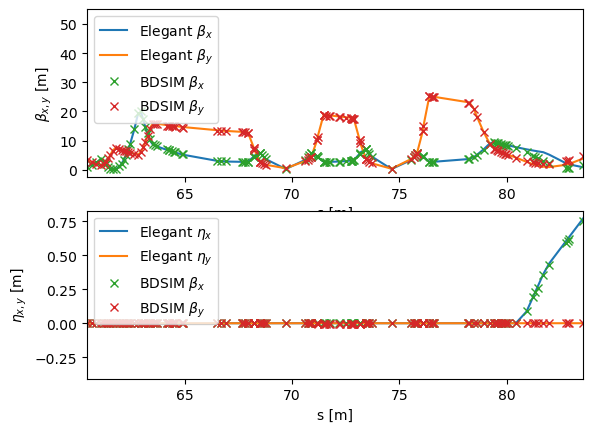

In [6]:
elegant_twi = sdds.load("../Run/FEBE.twi")

e_names = np.array(elegant_twi.getColumnValueList("ElementName"))
e_s = np.array(elegant_twi.getColumnValueList("s"))
e_betax = np.array(elegant_twi.getColumnValueList("betax"))
e_betay = np.array(elegant_twi.getColumnValueList("betay"))
e_etax = np.array(elegant_twi.getColumnValueList("etax"))
e_etay = np.array(elegant_twi.getColumnValueList("etay"))

e_idx0 = np.where(e_names == "CLA-FEA-SIM-DIP-04-END")[0] # TODO not sure about this offset 
e_idxN = np.where(e_names == "CLA-FED-SIM-DUMP-01-START")[0]


plt.subplot(2,1,1)
plt.plot(e_s, e_betax, label="Elegant $\\beta_x$")
plt.plot(e_s, e_betay, label="Elegant $\\beta_y$")
plt.plot(po['S'] + e_s[e_idx0] , po['Beta_x'], "x", label="BDSIM $\\beta_x$")
plt.plot(po['S'] + e_s[e_idx0] , po['Beta_y'], "x", label="BDSIM $\\beta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\beta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
#plt.xlim(e_s[e_idx0], e_s[e_idx0]+2);
plt.legend()

plt.subplot(2,1,2)
plt.plot(e_s, e_etax, label="Elegant $\\eta_x$")
plt.plot(e_s, e_etay, label="Elegant $\\eta_y$")
plt.plot(po['S'] + e_s[e_idx0] , po['Disp_x'], "x", label="BDSIM $\\beta_x$")
plt.plot(po['S'] + e_s[e_idx0] , po['Disp_y'], "x", label="BDSIM $\\beta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\eta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend(loc=2)

plt.savefig("Impact_ElegantComparision.jpg")